# Part I — Data Loading and Environment Setup
- Initialize analysis environment and load processed dataset.
- Automated path resolution ensures reproducibility across machines.
- Configure display options for effective data inspection.

In [57]:
# Step 1: Setup and Automatic Dataset Loading



from pathlib import Path



import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns



# Plotting & Pandas display settings

plt.style.use("seaborn-v0_8")

sns.set(font_scale=1.1)



pd.set_option("display.max_columns", 100)

pd.set_option("display.width", 140)



# Find project root by walking up until a folder containing `data/` is found

def find_project_root(marker: str = "data") -> Path:

    cwd = Path.cwd()

    for path in (cwd, *cwd.parents):

        if (path / marker).exists():

            return path

    raise FileNotFoundError(f"Could not find project root containing '{marker}' directory from {cwd}")



PROJECT_ROOT = find_project_root()



# Construct path to processed dataset inside repo

DATA_PATH = PROJECT_ROOT / "notebooks" / "model_ready_dataset.csv"



# Load dataset

df = pd.read_csv(DATA_PATH)



print(f"Loaded dataset from: {DATA_PATH}")

print("Shape:", df.shape)



df.head()


Loaded dataset from: c:\Users\reset\OneDrive - UWE Bristol\Master_project\UK-inflation-forecasting-XAI\notebooks\model_ready_dataset.csv
Shape: (327, 18)


,date,cpi_yoy,petrol_yoy,bank_rate,fx_usd,gva_growth,unemp_rate,cpi_yoy_l1,cpi_yoy_l3,cpi_yoy_l6,petrol_yoy_l1,fx_usd_l1,bank_rate_l1,gva_growth_l1,unemp_rate_l1,cpi_t1,cpi_t3,cpi_t5
0,1997-12-01,1.7,3.4,5.9375,1.6597,1.4,6.4,1.9,1.8,1.7,7.5,1.6890,5.9375,1.0,6.5,1.5,1.7,2.0
1,1998-01-01,1.5,3.2,7.2500,1.6353,1.4,6.4,1.7,1.9,2.0,3.4,1.6597,5.9375,1.4,6.4,1.6,1.8,1.7
2,1998-02-01,1.6,2.9,7.2500,1.6407,1.4,6.4,1.5,1.9,2.0,3.2,1.6353,7.2500,1.4,6.4,1.7,2.0,1.4
3,1998-03-01,1.7,3.3,7.2500,1.6620,0.8,6.3,1.6,1.7,1.8,2.9,1.6407,7.2500,1.4,6.4,1.8,1.7,1.3
4,1998-04-01,1.8,10.0,7.2500,1.6733,0.9,6.3,1.7,1.5,1.9,3.3,1.6620,7.2500,0.8,6.3,2.0,1.4,1.4


## 2. Hybrid Ensemble Framework Overview
- Lookback window: 18 months for medium-term temporal dynamics.
- Temporal splits: Train (≤ 2017-12-31), Validation (2018–2021), Test (2022+).
- Targets: CPI YoY forecasts at 1-month, 3-month, and 5-month horizons.
- Approach A (Averaging): Average scaled LSTM and XGBoost predictions, then inverse-scale.
- Approach B (Stacking): Augment features with LSTM predictions; train XGBoost regressors per horizon.
- Evaluation: MAE, RMSE, R² per model, split, and horizon.

In [58]:
# Setup for hybrid ensemble (lookback=18) and package checks
import subprocess, sys

try:
    import torch
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "-q"])
    import torch

try:
    import xgboost as xgb
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "-q"])
    import xgboost as xgb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

plt.style.use("seaborn-v0_8")
sns.set(font_scale=1.05)

lookback = 18

# Reuse loaded df from Cell 2
if 'df' not in globals():
    raise RuntimeError("Dataset not loaded; run the data loading cell first.")

# Ensure date
if 'date' not in df.columns:
    raise ValueError("'date' column missing; cannot split temporally.")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

train_end = '2017-12-31'
val_end = '2021-12-31'
train_mask = df['date'] <= train_end
val_mask = (df['date'] > train_end) & (df['date'] <= val_end)
test_mask = df['date'] > val_end

feature_cols = ['cpi_yoy', 'petrol_yoy', 'bank_rate', 'fx_usd', 'gva_growth', 'unemp_rate',
                'cpi_yoy_l1', 'cpi_yoy_l3', 'cpi_yoy_l6', 'petrol_yoy_l1', 'fx_usd_l1',
                'bank_rate_l1', 'gva_growth_l1', 'unemp_rate_l1']
target_cols = ['cpi_t1', 'cpi_t3', 'cpi_t5']

X_all = df[feature_cols].values
y_all = df[target_cols].values

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = scaler_X.fit_transform(X_all[train_mask.values])
X_val = scaler_X.transform(X_all[val_mask.values])
X_test = scaler_X.transform(X_all[test_mask.values])

y_train = scaler_y.fit_transform(y_all[train_mask.values])
y_val = scaler_y.transform(y_all[val_mask.values])
y_test = scaler_y.transform(y_all[test_mask.values])

print("Splits:")
print(f"Train: {train_mask.sum()} rows, Val: {val_mask.sum()} rows, Test: {test_mask.sum()} rows")
print("Scaled feature shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Scaled target shapes:", y_train.shape, y_val.shape, y_test.shape)

Splits:
Train: 241 rows, Val: 48 rows, Test: 38 rows
Scaled feature shapes: (241, 14) (48, 14) (38, 14)
Scaled target shapes: (241, 3) (48, 3) (38, 3)


## 2.1 Sequence Construction and Tabular Alignment
- Build 18-month supervised sequences for LSTM.
- Align tabular rows by discarding first `lookback` observations per split.
- Ensure LSTM targets match tabular feature rows for ensemble compatibility.
- Configure DataLoaders for stable training.

In [59]:
# Build sequences and aligned tabular sets

def create_sequences(X, y, lb):
    X_seq, y_seq = [], []
    for i in range(len(X) - lb):
        X_seq.append(X[i:i+lb])
        y_seq.append(y[i+lb])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, lookback)
X_val_seq, y_val_seq = create_sequences(X_val, y_val, lookback)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, lookback)

# Tabular rows aligned to sequence targets (drop first lookback rows per split)
X_train_tab = X_train[lookback:]
X_val_tab = X_val[lookback:]
X_test_tab = X_test[lookback:]

y_train_tab = y_train_seq  # aligned already

y_val_tab = y_val_seq

y_test_tab = y_test_seq

print("Sequence shapes:")
print("train", X_train_seq.shape, y_train_seq.shape)
print("val  ", X_val_seq.shape, y_val_seq.shape)
print("test ", X_test_seq.shape, y_test_seq.shape)

# Tensors and loaders
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_seq, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_seq, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_seq, dtype=torch.float32)

batch_size = 16
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=False)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=batch_size, shuffle=False)

test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)

print(f"Loaders ready (batch={batch_size})")

Sequence shapes:
train (223, 18, 14) (223, 3)
val   (30, 18, 14) (30, 3)
test  (20, 18, 14) (20, 3)
Loaders ready (batch=16)


## 2.2 LSTM Baseline Configuration and Training
- Architecture: single-layer LSTM, hidden size 64, dropout 0.2.
- Optimizer: Adam (lr = 0.001), Loss: MSE.
- Training: max 150 epochs with early stopping (patience = 15) on validation loss.
- Predictions: generate scaled outputs and apply inverse transformation to CPI YoY levels.

# Part II — LSTM Baseline Forecasting
- Build supervised sequences with 18-month lookback.
- Configure and train LSTM baseline model.
- Generate horizon-wise predictions with performance metrics.
- Visualize time-series comparisons and predicted-vs-actual calibration.

## LSTM Baseline — Quick Reference
| Component | Details |
|-----------|---------|
| **Targets** | `cpi_t1`, `cpi_t3`, `cpi_t5` (CPI YoY forecasts at 1M, 3M, 5M horizons) |
| **Features** | 18-month sequential window of scaled features: `cpi_yoy`, `petrol_yoy`, `bank_rate`, `fx_usd`, `gva_growth`, `unemp_rate`, plus lagged versions |
| **Output** | Scaled predictions → inverse-scaled to CPI YoY |

In [60]:
# Define and train LSTM
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, dropout=0.2, output_size=3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True,
                           dropout=dropout if num_layers > 1 else 0)
        self.drop1 = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size, 32)
        self.drop2 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(32, output_size)
    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        x = self.drop1(last)
        x = torch.relu(self.fc1(x))
        x = self.drop2(x)
        return self.fc2(x)

input_size = X_train_seq.shape[2]
model = LSTMForecaster(input_size=input_size)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 150
patience = 15
best_val = float('inf')
pat = 0
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    if val_loss < best_val:
        best_val = val_loss
        best_state = model.state_dict().copy()
        pat = 0
    else:
        pat += 1

    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} | Train {train_loss:.4f} | Val {val_loss:.4f}")

    if pat >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

model.load_state_dict(best_state)
print(f"Best val loss: {best_val:.4f}")


Early stopping at epoch 17
Best val loss: 0.1223


### LSTM Predictions: Time-Series Visualization
- Three figures (one per horizon) with Train/Validation/Test panels.
- Lines: Actual (solid circles) vs Predicted (dashed squares).
- Annotations: MAE and RMSE per split and horizon.
- Axis standardization: annual ticks for clarity across periods.

LSTM predictions ready (scaled and inverse-scaled)


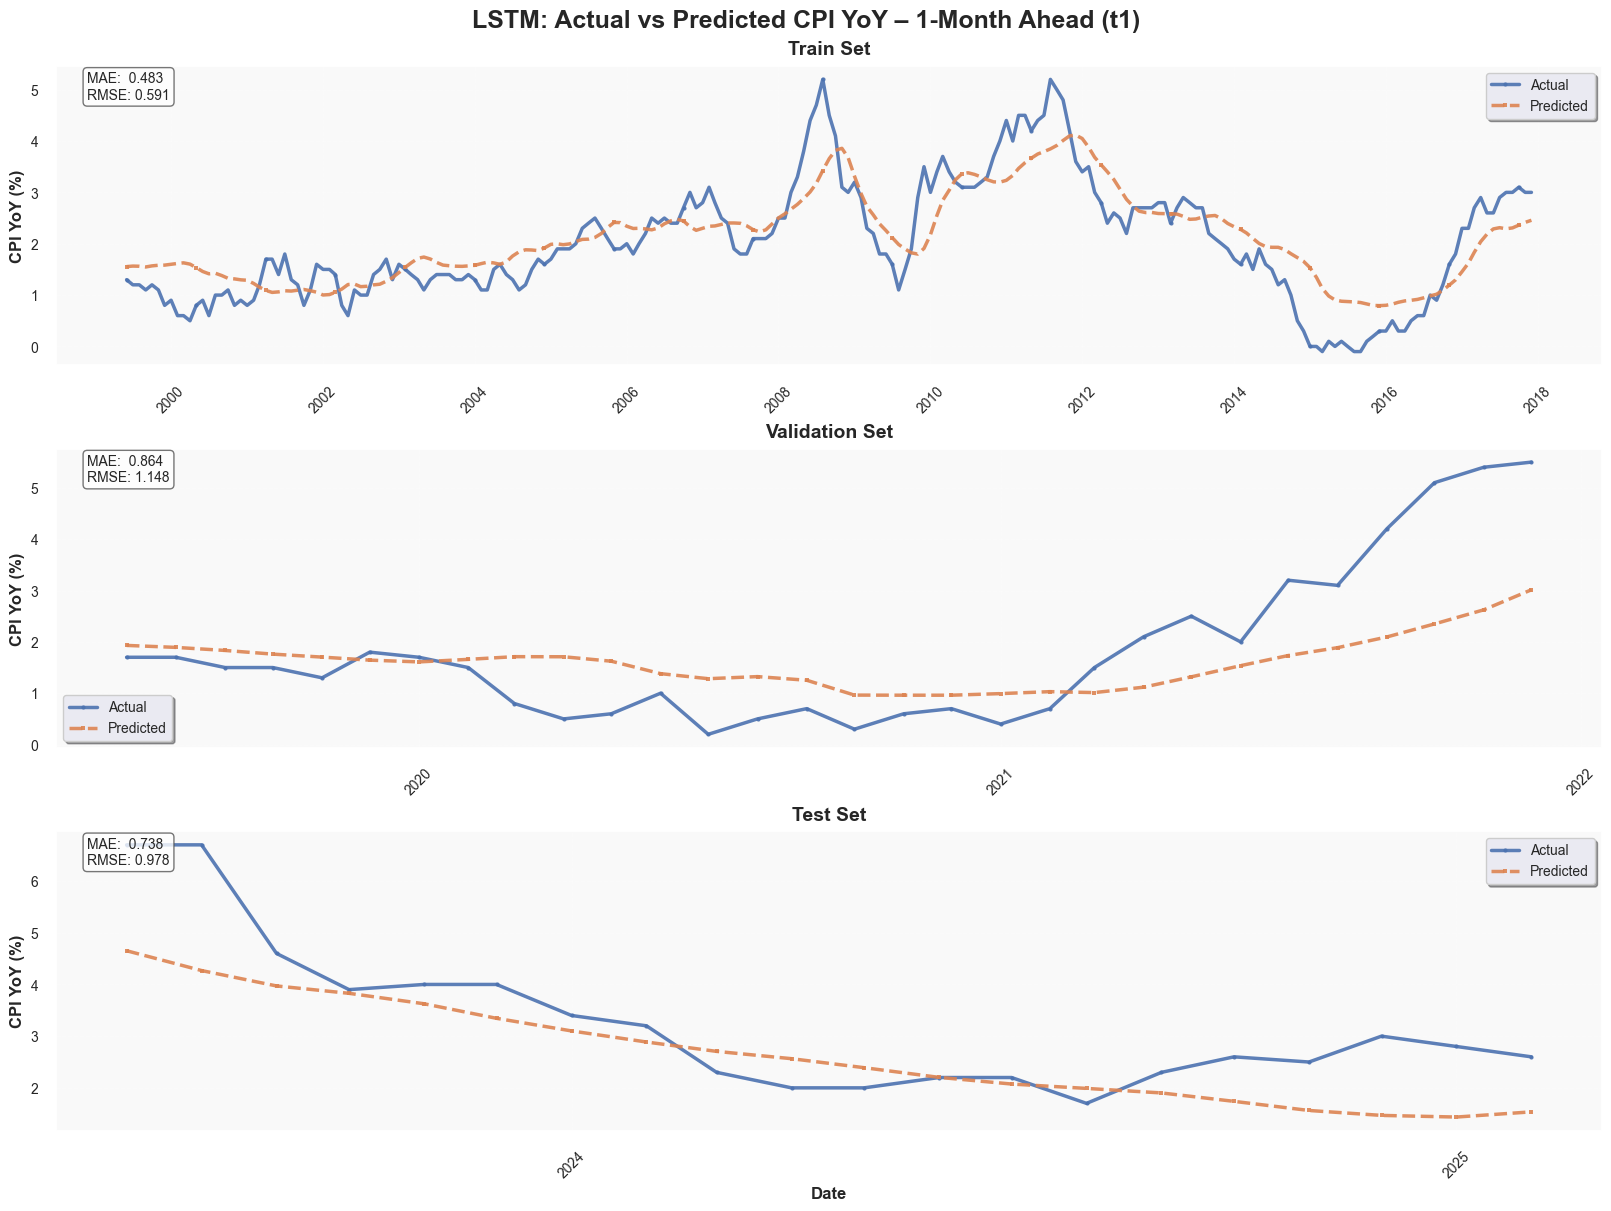

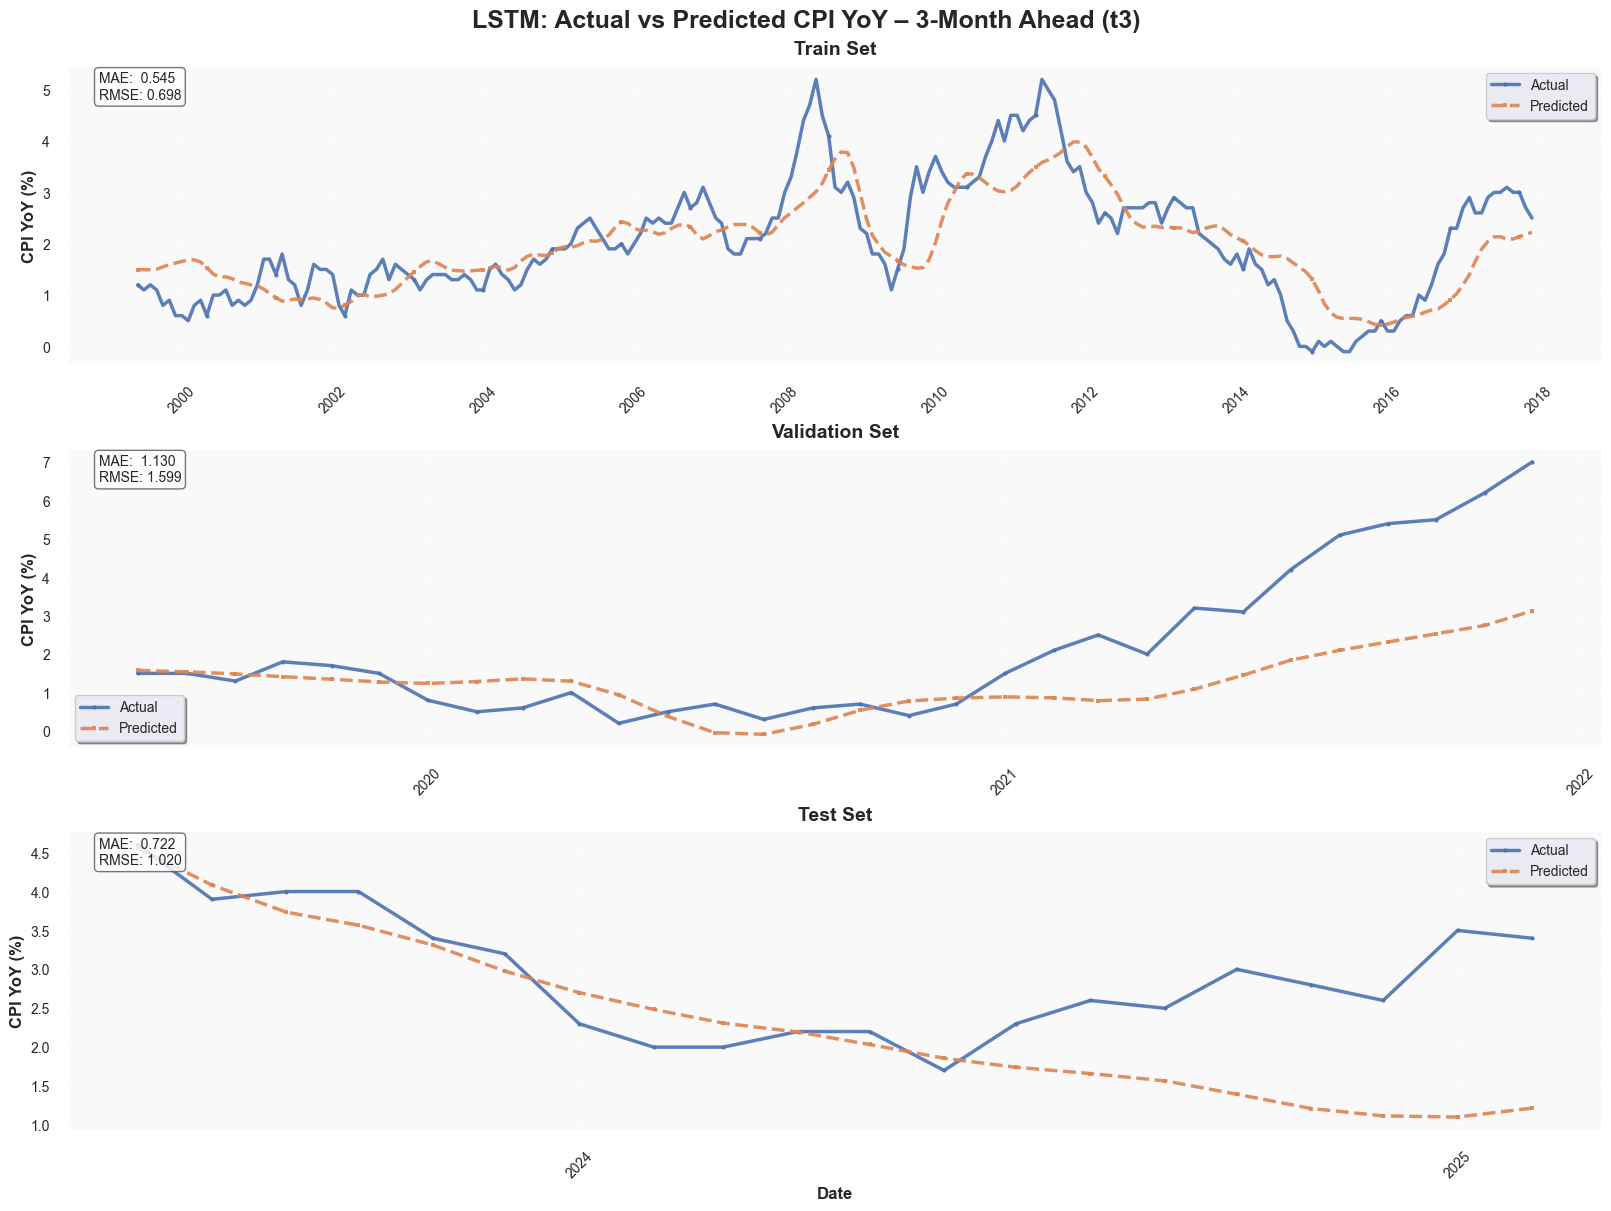

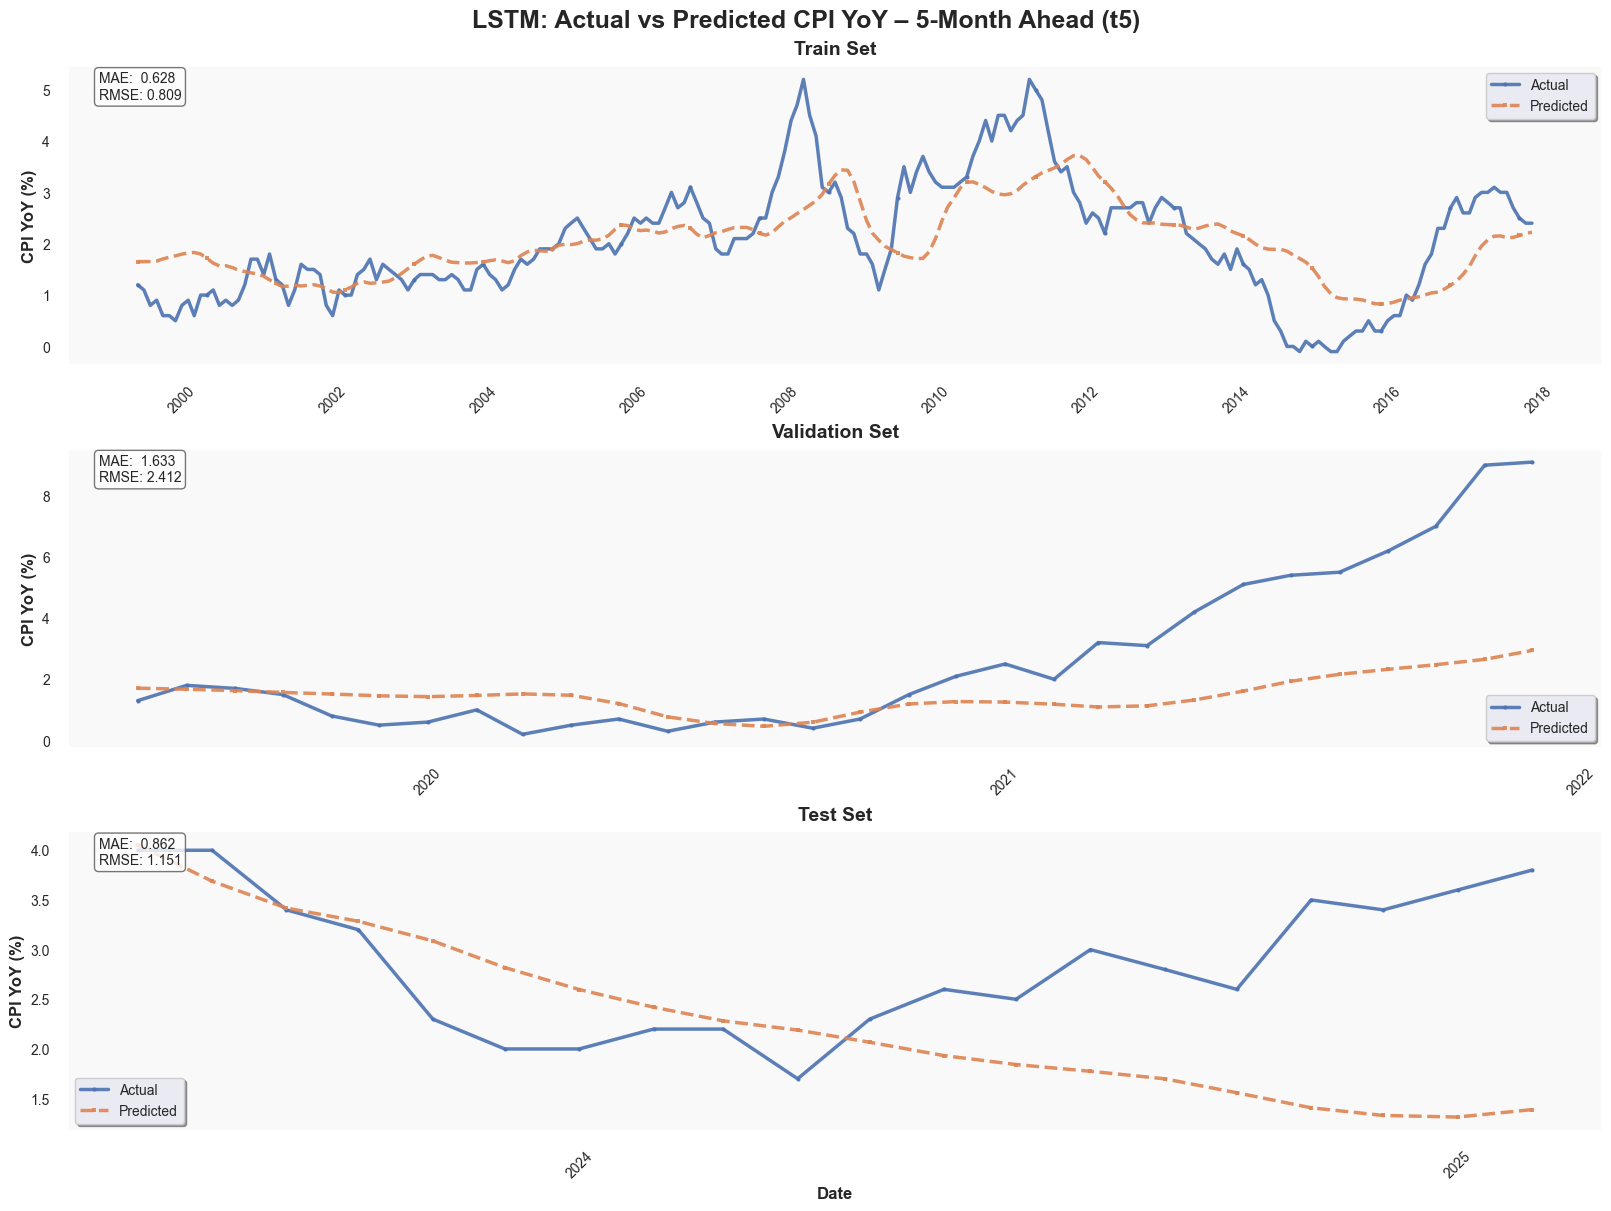

In [61]:
# LSTM predictions + clear horizon-wise plots (Train / Val / Test)

from math import sqrt
import matplotlib.dates as mdates

# 1) Predict with trained LSTM (in scaled space) and inverse-transform to real CPI YoY
model.eval()
with torch.no_grad():
    y_train_pred_scaled = model(X_train_tensor).cpu().numpy()
    y_val_pred_scaled = model(X_val_tensor).cpu().numpy()
    y_test_pred_scaled = model(X_test_tensor).cpu().numpy()

y_train_actual = scaler_y.inverse_transform(y_train_seq)
y_val_actual = scaler_y.inverse_transform(y_val_seq)
y_test_actual = scaler_y.inverse_transform(y_test_seq)

y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled)
y_val_pred = scaler_y.inverse_transform(y_val_pred_scaled)
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled)

print("LSTM predictions ready (scaled and inverse-scaled)")

# 2) Prepare split data and aligned dates (drop first lookback rows for sequences)
split_data = {
    "Train": (
        y_train_actual,
        y_train_pred,
        df[train_mask]["date"].values[lookback:]
    ),
    "Validation": (
        y_val_actual,
        y_val_pred,
        df[val_mask]["date"].values[lookback:]
    ),
    "Test": (
        y_test_actual,
        y_test_pred,
        df[test_mask]["date"].values[lookback:]
    ),
}

# (index in target arrays, label for title)
horizon_info = [
    (0, "1-Month Ahead (t1)"),
    (1, "3-Month Ahead (t3)"),
    (2, "5-Month Ahead (t5)"),
]

# 3) Plot: one figure per horizon, with 3 rows (Train / Val / Test)
for h_idx, h_label in horizon_info:
    fig, axes = plt.subplots(
        nrows=3,
        ncols=1,
        figsize=(16, 12),
        constrained_layout=True
    )
    fig.suptitle(
        f"LSTM: Actual vs Predicted CPI YoY – {h_label}",
        fontsize=18,
        fontweight="bold"
    )

    # Ensure axes is iterable
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])

    for ax, (split_name, (y_actual_all, y_pred_all, dates)) in zip(axes, split_data.items()):
        # Select this horizon
        actual_vals = y_actual_all[:, h_idx]
        pred_vals   = y_pred_all[:, h_idx]

        # Time series plot: Actual vs Predicted
        ax.plot(
            dates,
            actual_vals,
            label="Actual",
            linewidth=2.5,
            marker="o",
            markersize=3,
            markevery=max(1, len(dates) // 20),
            alpha=0.9,
        )
        ax.plot(
            dates,
            pred_vals,
            label="Predicted",
            linewidth=2.5,
            linestyle="--",
            marker="s",
            markersize=3,
            markevery=max(1, len(dates) // 20),
            alpha=0.9,
        )

        # Titles & labels
        ax.set_title(f"{split_name} Set", fontsize=14, fontweight="bold", pad=8)
        ax.set_ylabel("CPI YoY (%)", fontsize=12, fontweight="bold")
        ax.grid(True, alpha=0.3, linestyle="--", linewidth=0.8)
        ax.tick_params(axis="x", rotation=45, labelsize=10)
        ax.tick_params(axis="y", labelsize=10)
        ax.set_facecolor("#F9F9F9")

        # Less crowded time axis
        if split_name == "Train":
            # Long period → tick every 2 years
            ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        else:
            # Shorter periods → yearly ticks
            ax.xaxis.set_major_locator(mdates.YearLocator())
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

        # Metrics: MAE and RMSE for this split + horizon
        mae_val = mean_absolute_error(actual_vals, pred_vals)
        rmse_val = sqrt(mean_squared_error(actual_vals, pred_vals))

        ax.text(
            0.02,
            0.98,
            f"MAE:  {mae_val:.3f}\nRMSE: {rmse_val:.3f}",
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment="top",
            bbox=dict(
                boxstyle="round",
                facecolor="white",
                alpha=0.8,
                edgecolor="#555555",
            ),
        )

        ax.legend(loc="best", frameon=True, shadow=True, fontsize=10)

    axes[-1].set_xlabel("Date", fontsize=12, fontweight="bold")
    plt.show()


## 3. Hybrid Approach A: Averaging
- Train horizon-specific XGBoost regressors on aligned tabular features.
- Apply early stopping on validation set.
- Average scaled LSTM and XGBoost predictions.
- Inverse-scale to recover CPI YoY values.
- Visualize predicted vs actual for all splits and horizons.

## Hybrid Approach A (Averaging) — Quick Reference
| Component | Details |
|-----------|---------|
| **Targets** | `cpi_t1`, `cpi_t3`, `cpi_t5` (same as LSTM) |
| **Features (XGBoost)** | 14 tabular features: `cpi_yoy`, `petrol_yoy`, `bank_rate`, `fx_usd`, `gva_growth`, `unemp_rate`, plus lagged versions (no sequences) |
| **Combination** | Average scaled LSTM outputs + scaled XGBoost predictions, then inverse-scale |
| **Output** | CPI YoY forecast combining sequence and tabular signals |

In [62]:
# XGBoost training for Approach A and averaging with LSTM (Hybrid)

xgb_params = dict(
    learning_rate=0.03,
    max_depth=5,
    n_estimators=400,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='reg:squarederror',
    tree_method='hist'
)

horizons = ['t1', 't3', 't5']
horizon_idx = {'t1': 0, 't3': 1, 't5': 2}
xgb_models_A = {}

# Train one XGBoost model per horizon with early stopping
for h in horizons:
    idx = horizon_idx[h]
    dtrain = xgb.DMatrix(X_train_tab, label=y_train_tab[:, idx])
    dval = xgb.DMatrix(X_val_tab, label=y_val_tab[:, idx])
    model = xgb.train(
        params=xgb_params,
        dtrain=dtrain,
        num_boost_round=2000,
        evals=[(dval, 'val')],
        early_stopping_rounds=50,
        verbose_eval=False
    )
    xgb_models_A[h] = model

# XGBoost predictions (still in scaled target space)
y_train_pred_xgb = np.column_stack([
    xgb_models_A[h].predict(xgb.DMatrix(X_train_tab)) for h in horizons
])
y_val_pred_xgb = np.column_stack([
    xgb_models_A[h].predict(xgb.DMatrix(X_val_tab)) for h in horizons
])
y_test_pred_xgb = np.column_stack([
    xgb_models_A[h].predict(xgb.DMatrix(X_test_tab)) for h in horizons
])

# Hybrid averaging with LSTM (still scaled)
y_train_avg_scaled = 0.5 * y_train_pred_scaled + 0.5 * y_train_pred_xgb
y_val_avg_scaled   = 0.5 * y_val_pred_scaled   + 0.5 * y_val_pred_xgb
y_test_avg_scaled  = 0.5 * y_test_pred_scaled  + 0.5 * y_test_pred_xgb

# Inverse scale to get CPI YoY values
ensembleA_train = scaler_y.inverse_transform(y_train_avg_scaled)
ensembleA_val   = scaler_y.inverse_transform(y_val_avg_scaled)
ensembleA_test  = scaler_y.inverse_transform(y_test_avg_scaled)

print("Approach A: XGBoost trained & averaged with LSTM (hybrid predictions ready).")


c:\Users\reset\OneDrive - UWE Bristol\Master_project\UK-inflation-forecasting-XAI\.venv\Lib\site-packages\xgboost\callback.py:386: UserWarning: [23:25:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "n_estimators" } are not used.

  self.starting_round = model.num_boosted_rounds()
c:\Users\reset\OneDrive - UWE Bristol\Master_project\UK-inflation-forecasting-XAI\.venv\Lib\site-packages\xgboost\callback.py:386: UserWarning: [23:25:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "n_estimators" } are not used.

  self.starting_round = model.num_boosted_rounds()
c:\Users\reset\OneDrive - UWE Bristol\Master_project\UK-inflation-forecasting-XAI\.venv\Lib\site-packages\xgboost\callback.py:386: UserWarning: [23:25:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "n_estimators" } are not used.

  self.starting_round = model.num_boosted_rounds()


Approach A: XGBoost trained & averaged with LSTM (hybrid predictions ready).


Hybrid Ensemble (Approach A): plotting actual vs predicted CPI YoY.


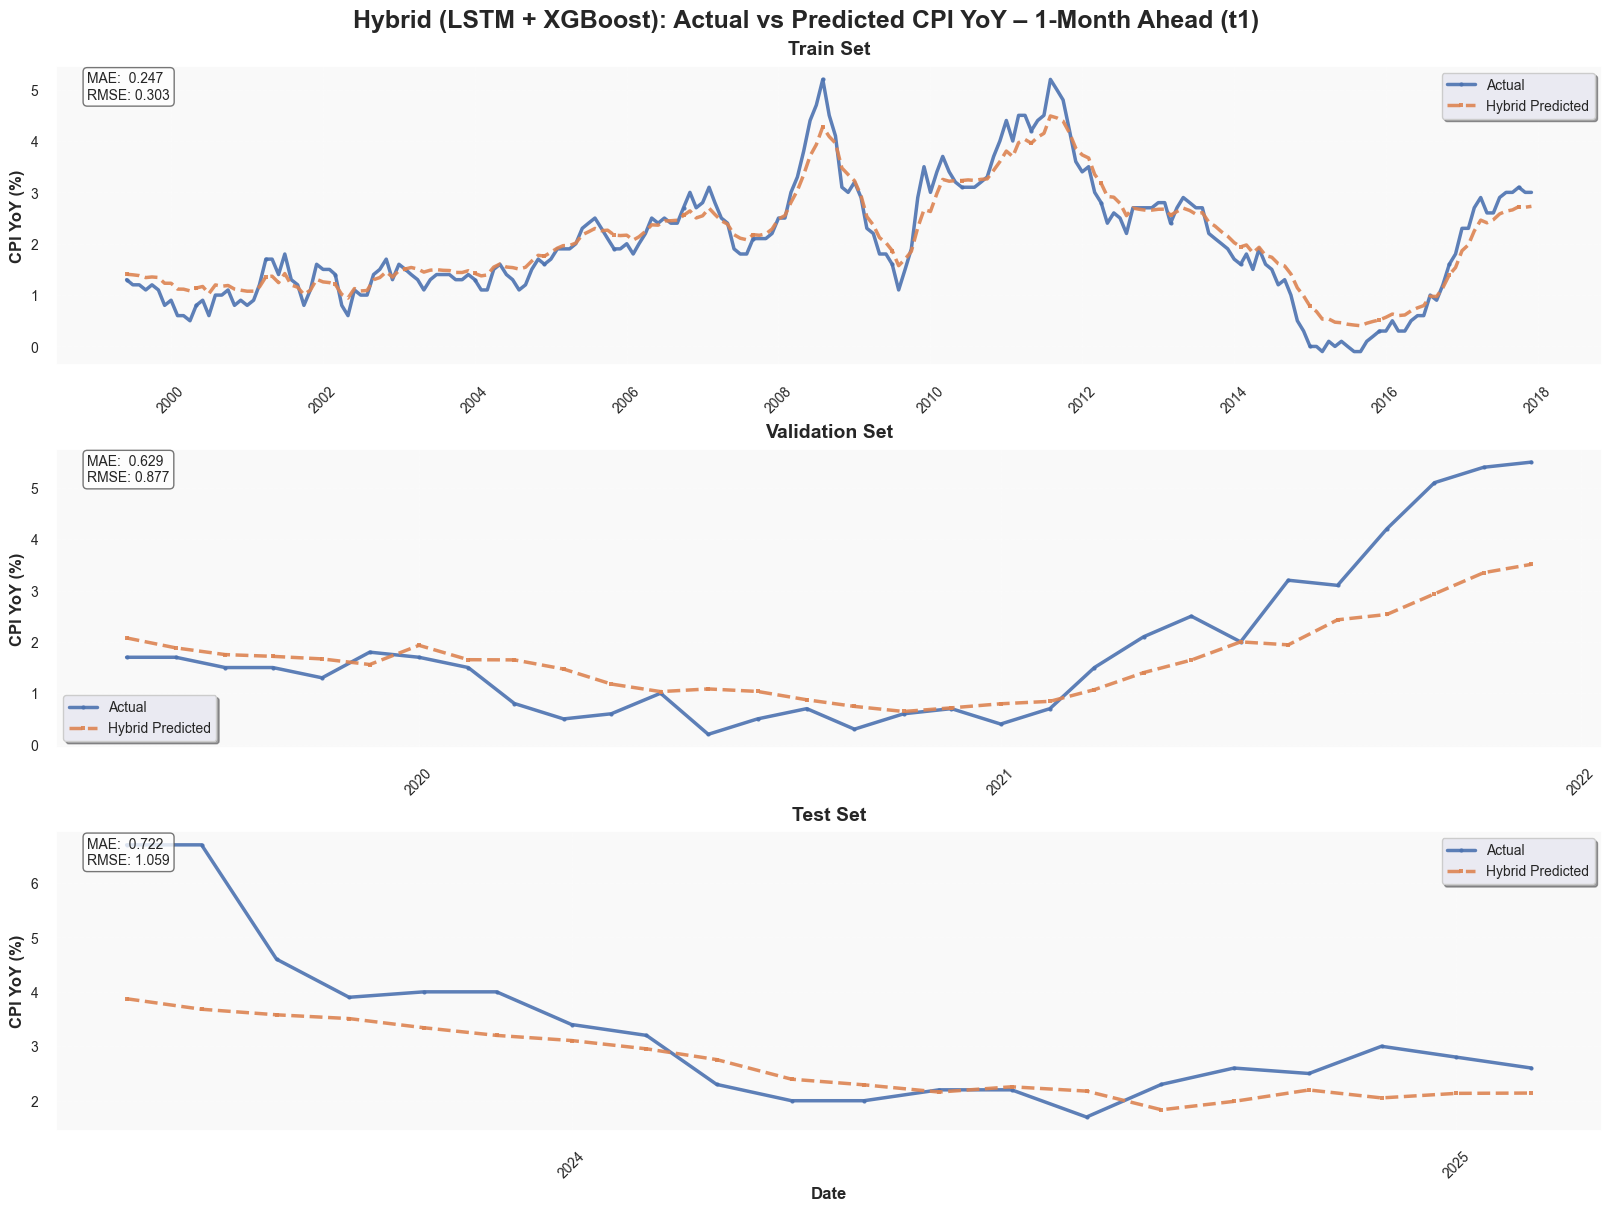

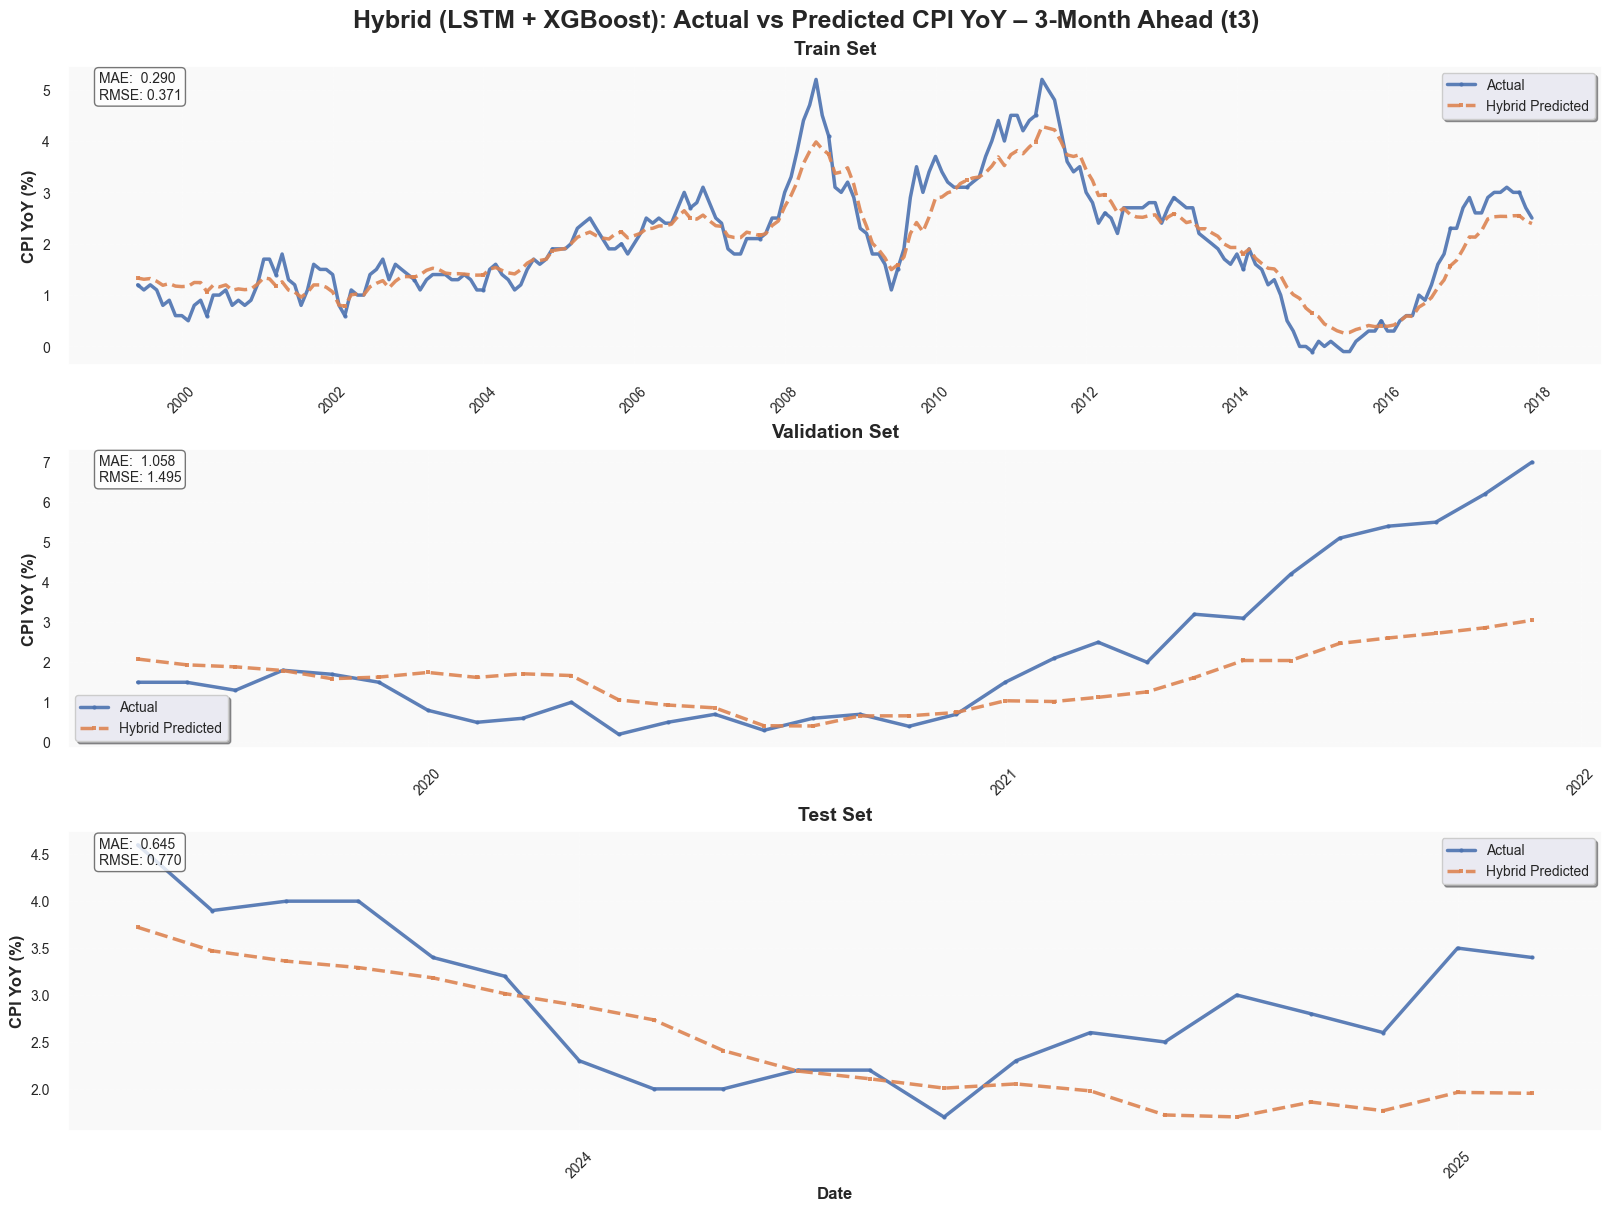

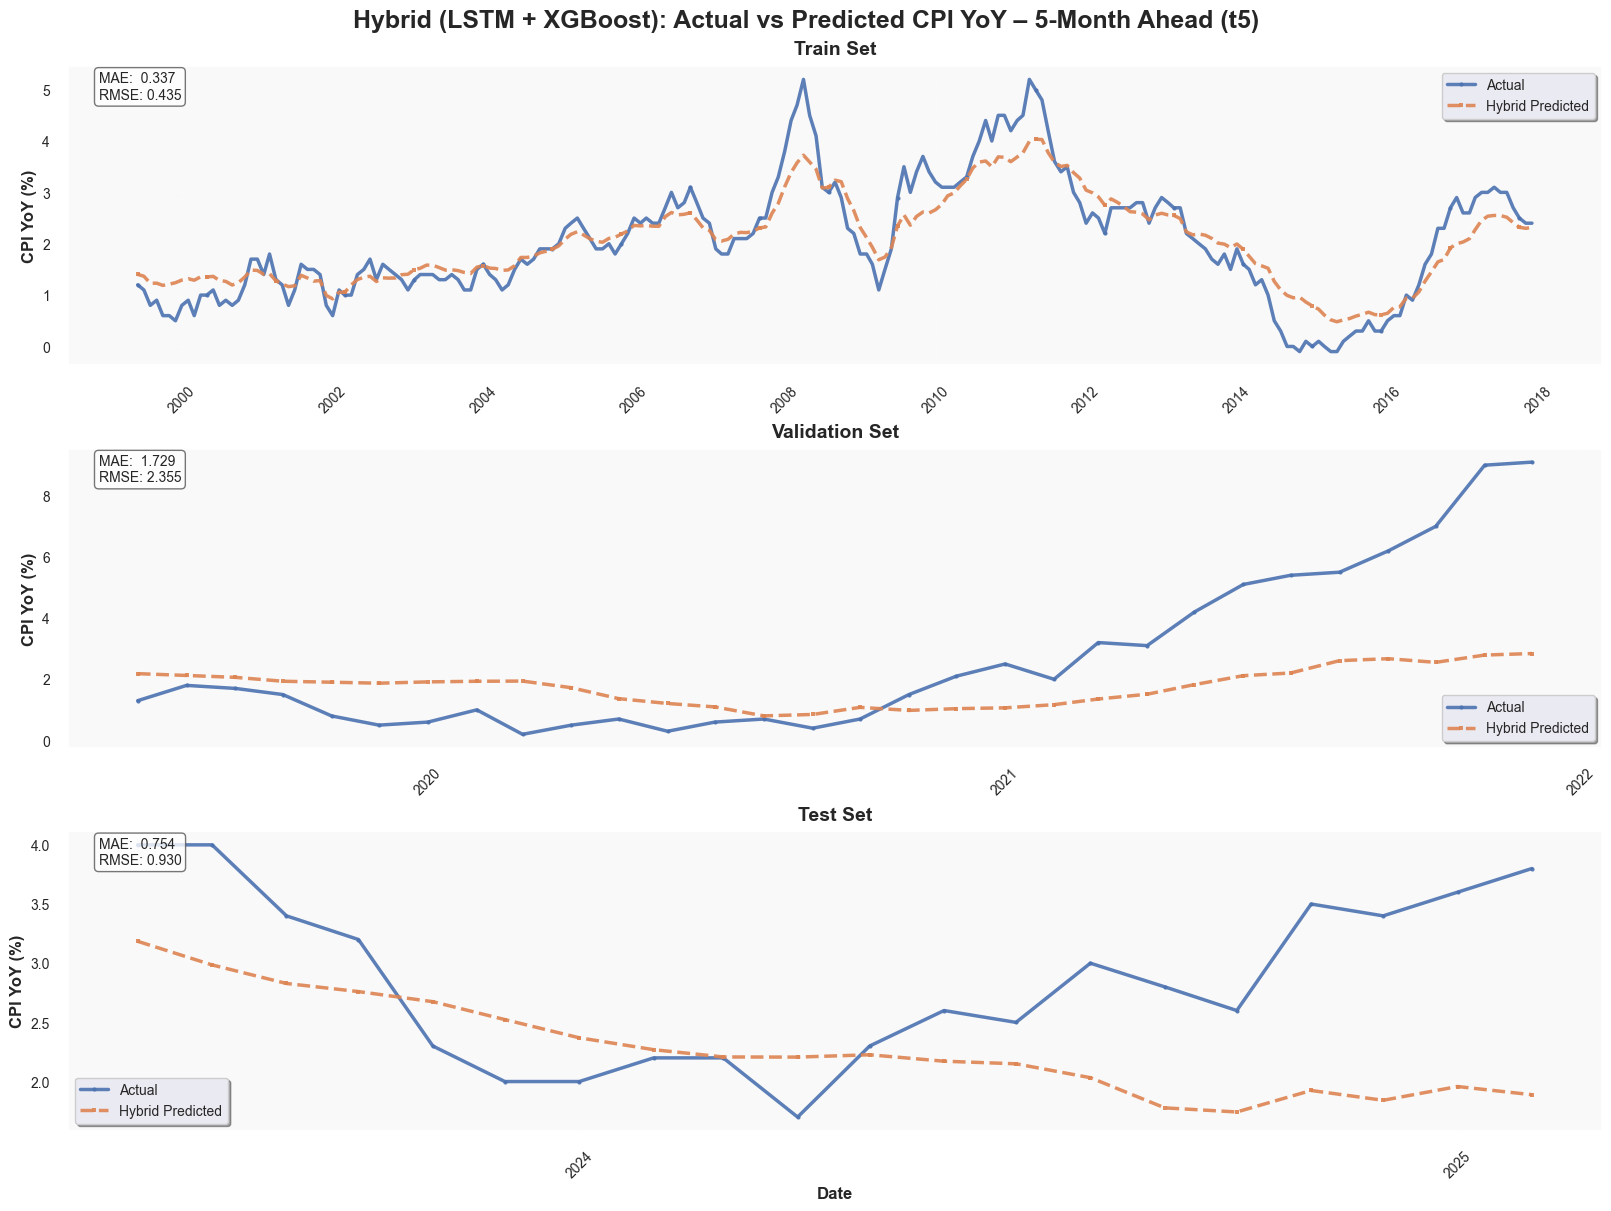

In [63]:
# Hybrid (LSTM + XGBoost) – Actual vs Predicted plots with MAE & RMSE

from math import sqrt
import matplotlib.dates as mdates

print("Hybrid Ensemble (Approach A): plotting actual vs predicted CPI YoY.")

# Prepare split data: actual CPI vs HYBRID predictions (already inverse-scaled)
hybrid_split_data = {
    "Train": (
        y_train_actual,        # true CPI YoY
        ensembleA_train,       # hybrid predictions
        df[train_mask]["date"].values[lookback:]
    ),
    "Validation": (
        y_val_actual,
        ensembleA_val,
        df[val_mask]["date"].values[lookback:]
    ),
    "Test": (
        y_test_actual,
        ensembleA_test,
        df[test_mask]["date"].values[lookback:]
    ),
}

# (index in targets, label for figure title)
horizon_info = [
    (0, "1-Month Ahead (t1)"),
    (1, "3-Month Ahead (t3)"),
    (2, "5-Month Ahead (t5)"),
]

# Plot: one figure per horizon, with Train / Val / Test stacked
for h_idx, h_label in horizon_info:
    fig, axes = plt.subplots(
        nrows=3,
        ncols=1,
        figsize=(16, 12),
        constrained_layout=True
    )
    fig.suptitle(
        f"Hybrid (LSTM + XGBoost): Actual vs Predicted CPI YoY – {h_label}",
        fontsize=18,
        fontweight="bold"
    )

    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])

    for ax, (split_name, (y_actual_all, y_pred_all, dates)) in zip(axes, hybrid_split_data.items()):
        # Select this horizon
        actual_vals = y_actual_all[:, h_idx]
        pred_vals   = y_pred_all[:, h_idx]

        # Time series plot: Actual vs Hybrid Predicted
        ax.plot(
            dates,
            actual_vals,
            label="Actual",
            linewidth=2.5,
            marker="o",
            markersize=3,
            markevery=max(1, len(dates) // 20),
            alpha=0.9,
        )
        ax.plot(
            dates,
            pred_vals,
            label="Hybrid Predicted",
            linewidth=2.5,
            linestyle="--",
            marker="s",
            markersize=3,
            markevery=max(1, len(dates) // 20),
            alpha=0.9,
        )

        # Titles & labels
        ax.set_title(f"{split_name} Set", fontsize=14, fontweight="bold", pad=8)
        ax.set_ylabel("CPI YoY (%)", fontsize=12, fontweight="bold")
        ax.grid(True, alpha=0.3, linestyle="--", linewidth=0.8)
        ax.tick_params(axis="x", rotation=45, labelsize=10)
        ax.tick_params(axis="y", labelsize=10)
        ax.set_facecolor("#F9F9F9")

        # Cleaner time axis (less crowded)
        if split_name == "Train":
            # Long period → tick every 2 years
            ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        else:
            # Shorter periods → yearly ticks
            ax.xaxis.set_major_locator(mdates.YearLocator())
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

        # Metrics: MAE and RMSE for this split + horizon
        mae_val = mean_absolute_error(actual_vals, pred_vals)
        rmse_val = sqrt(mean_squared_error(actual_vals, pred_vals))

        ax.text(
            0.02,
            0.98,
            f"MAE:  {mae_val:.3f}\nRMSE: {rmse_val:.3f}",
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment="top",
            bbox=dict(
                boxstyle="round",
                facecolor="white",
                alpha=0.8,
                edgecolor="#555555",
            ),
        )

        ax.legend(loc="best", frameon=True, shadow=True, fontsize=10)

    axes[-1].set_xlabel("Date", fontsize=12, fontweight="bold")
    plt.show()


### Hybrid Approach A: Predicted vs Actual
- Scatter plots: Actual CPI YoY (x-axis) vs Hybrid A Predicted (y-axis).
- Diagonal reference line indicates perfect agreement.
- 3×3 grid: Train/Validation/Test rows; t1/t3/t5 columns.
- Dispersion reflects prediction error magnitudes per split and horizon.

## 4. Hybrid Approach B: Stacking
- Augment tabular features with LSTM predictions across all horizons.
- Train horizon-specific XGBoost regressors with early stopping.
- Inverse-scale stacked predictions to CPI YoY.
- Visualize calibration and temporal performance across splits and horizons.

## Hybrid Approach B (Stacking) — Quick Reference
| Component | Details |
|-----------|---------|
| **Targets** | `cpi_t1`, `cpi_t3`, `cpi_t5` (same as LSTM) |
| **Features (XGBoost)** | 14 tabular features + 3 LSTM predictions (t1, t3, t5) = 17 stacked features per sample |
| **Combination** | XGBoost learns to leverage both tabular and LSTM-derived signals for each horizon |
| **Output** | CPI YoY forecast from XGBoost trained on augmented feature set |

In [64]:
# Stacking features include LSTM predictions
stack_train_X = np.hstack([X_train_tab, y_train_pred_scaled])
stack_val_X = np.hstack([X_val_tab, y_val_pred_scaled])
stack_test_X = np.hstack([X_test_tab, y_test_pred_scaled])

xgb_params_stack = dict(
    learning_rate=0.03,
    max_depth=6,
    n_estimators=500,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='reg:squarederror',
    tree_method='hist'
)

xgb_models_B = {}
for h in horizons:
    idx = horizon_idx[h]
    dtrain = xgb.DMatrix(stack_train_X, label=y_train_tab[:, idx])
    dval = xgb.DMatrix(stack_val_X, label=y_val_tab[:, idx])
    model = xgb.train(
        params=xgb_params_stack,
        dtrain=dtrain,
        num_boost_round=2000,
        evals=[(dval, 'val')],
        early_stopping_rounds=75,
        verbose_eval=False
    )
    xgb_models_B[h] = model

# Predict
stack_train_pred_scaled = np.column_stack([
    xgb_models_B[h].predict(xgb.DMatrix(stack_train_X)) for h in horizons
])
stack_val_pred_scaled = np.column_stack([
    xgb_models_B[h].predict(xgb.DMatrix(stack_val_X)) for h in horizons
])
stack_test_pred_scaled = np.column_stack([
    xgb_models_B[h].predict(xgb.DMatrix(stack_test_X)) for h in horizons
])

ensembleB_train = scaler_y.inverse_transform(stack_train_pred_scaled)
ensembleB_val = scaler_y.inverse_transform(stack_val_pred_scaled)
ensembleB_test = scaler_y.inverse_transform(stack_test_pred_scaled)

print("Approach B: stacking models trained")

c:\Users\reset\OneDrive - UWE Bristol\Master_project\UK-inflation-forecasting-XAI\.venv\Lib\site-packages\xgboost\callback.py:386: UserWarning: [23:25:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "n_estimators" } are not used.

  self.starting_round = model.num_boosted_rounds()
c:\Users\reset\OneDrive - UWE Bristol\Master_project\UK-inflation-forecasting-XAI\.venv\Lib\site-packages\xgboost\callback.py:386: UserWarning: [23:25:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "n_estimators" } are not used.

  self.starting_round = model.num_boosted_rounds()
c:\Users\reset\OneDrive - UWE Bristol\Master_project\UK-inflation-forecasting-XAI\.venv\Lib\site-packages\xgboost\callback.py:386: UserWarning: [23:25:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "n_estimators" } are not used.

  self.starting_round = model.num_boosted_rounds()


Approach B: stacking models trained


## 5. Evaluation Protocol
- Compute MAE, RMSE, R² per model, split, and horizon.
- Report results in tabular format for easy comparison.
- Structure: Models (LSTM, Hybrid A, Hybrid B) × Splits (Train/Val/Test) × Horizons (t1/t3/t5).

In [65]:
def metrics_block(y_true, y_pred):
    return {
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'r2': r2_score(y_true, y_pred)
    }

def collect_results(y_true_dict, y_pred_dict):
    out = {}
    for model_name, preds in y_pred_dict.items():
        out[model_name] = {}
        for split_name, (yt, yp) in y_true_dict.items():
            out[model_name][split_name] = [metrics_block(yt[:, i], yp[:, i]) for i in range(3)]
    return out

truth = {
    'train': (y_train_actual, {'lstm': y_train_pred, 'ensA': ensembleA_train, 'ensB': ensembleB_train}),
    'val':   (y_val_actual,   {'lstm': y_val_pred,   'ensA': ensembleA_val,   'ensB': ensembleB_val}),
    'test':  (y_test_actual,  {'lstm': y_test_pred,  'ensA': ensembleA_test,  'ensB': ensembleB_test})
}

models = ['lstm','ensA','ensB']
splits = ['train','val','test']
horizons = ['t1','t3','t5']

results = {m:{s:[] for s in splits} for m in models}

for s in splits:
    yt, yps = truth[s]
    for m in models:
        res = [metrics_block(yt[:, i], yps[m][:, i]) for i in range(3)]
        results[m][s] = res

# Pretty print table
print("="*90)
print("MAE / RMSE / R2 per model, split, horizon")
for m in models:
    print(f"\n[{m.upper()}]")
    for s in splits:
        vals = results[m][s]
        line = " | ".join([f"{h}: MAE {v['mae']:.3f} RMSE {v['rmse']:.3f} R2 {v['r2']:.3f}" for h,v in zip(horizons, vals)])
        print(f"{s:<5} -> {line}")
print("="*90)

MAE / RMSE / R2 per model, split, horizon

[LSTM]
train -> t1: MAE 0.483 RMSE 0.591 R2 0.738 | t3: MAE 0.545 RMSE 0.698 R2 0.634 | t5: MAE 0.628 RMSE 0.809 R2 0.507
val   -> t1: MAE 0.864 RMSE 1.148 R2 0.405 | t3: MAE 1.130 RMSE 1.599 R2 0.300 | t5: MAE 1.633 RMSE 2.412 R2 0.113
test  -> t1: MAE 0.738 RMSE 0.978 R2 0.502 | t3: MAE 0.722 RMSE 1.020 R2 -0.680 | t5: MAE 0.862 RMSE 1.151 R2 -1.716

[ENSA]
train -> t1: MAE 0.247 RMSE 0.303 R2 0.931 | t3: MAE 0.290 RMSE 0.371 R2 0.896 | t5: MAE 0.337 RMSE 0.435 R2 0.857
val   -> t1: MAE 0.629 RMSE 0.877 R2 0.653 | t3: MAE 1.058 RMSE 1.495 R2 0.387 | t5: MAE 1.729 RMSE 2.355 R2 0.154
test  -> t1: MAE 0.722 RMSE 1.059 R2 0.415 | t3: MAE 0.645 RMSE 0.770 R2 0.041 | t5: MAE 0.754 RMSE 0.930 R2 -0.776

[ENSB]
train -> t1: MAE 0.008 RMSE 0.010 R2 1.000 | t3: MAE 0.020 RMSE 0.029 R2 0.999 | t5: MAE 0.029 RMSE 0.043 R2 0.999
val   -> t1: MAE 0.472 RMSE 0.639 R2 0.816 | t3: MAE 1.087 RMSE 1.468 R2 0.410 | t5: MAE 1.928 RMSE 2.369 R2 0.144
test  -> t1

### Predicted vs Actual Grids (LSTM and Hybrid Models)
- Calibration assessment via scatter plots across splits and horizons.
- Diagonal reference: perfect agreement; dispersion reflects error.
- 3×3 layout per model for rapid visual comparison.

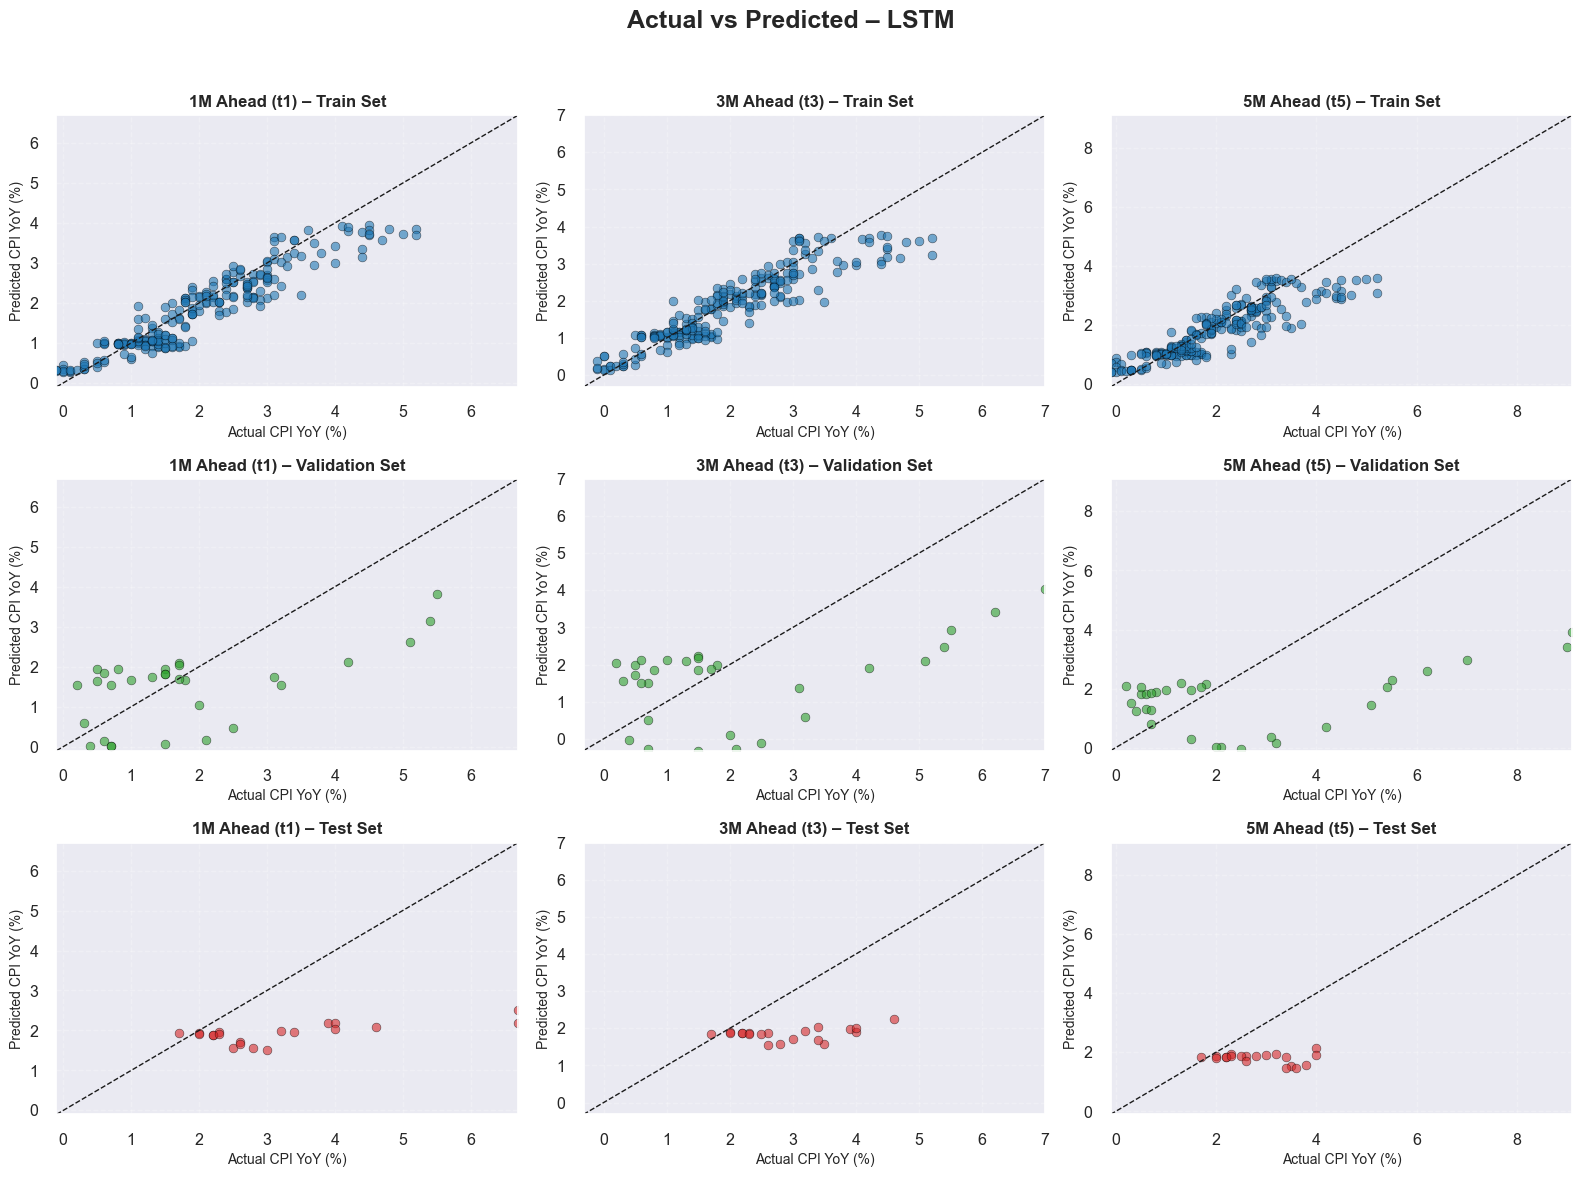

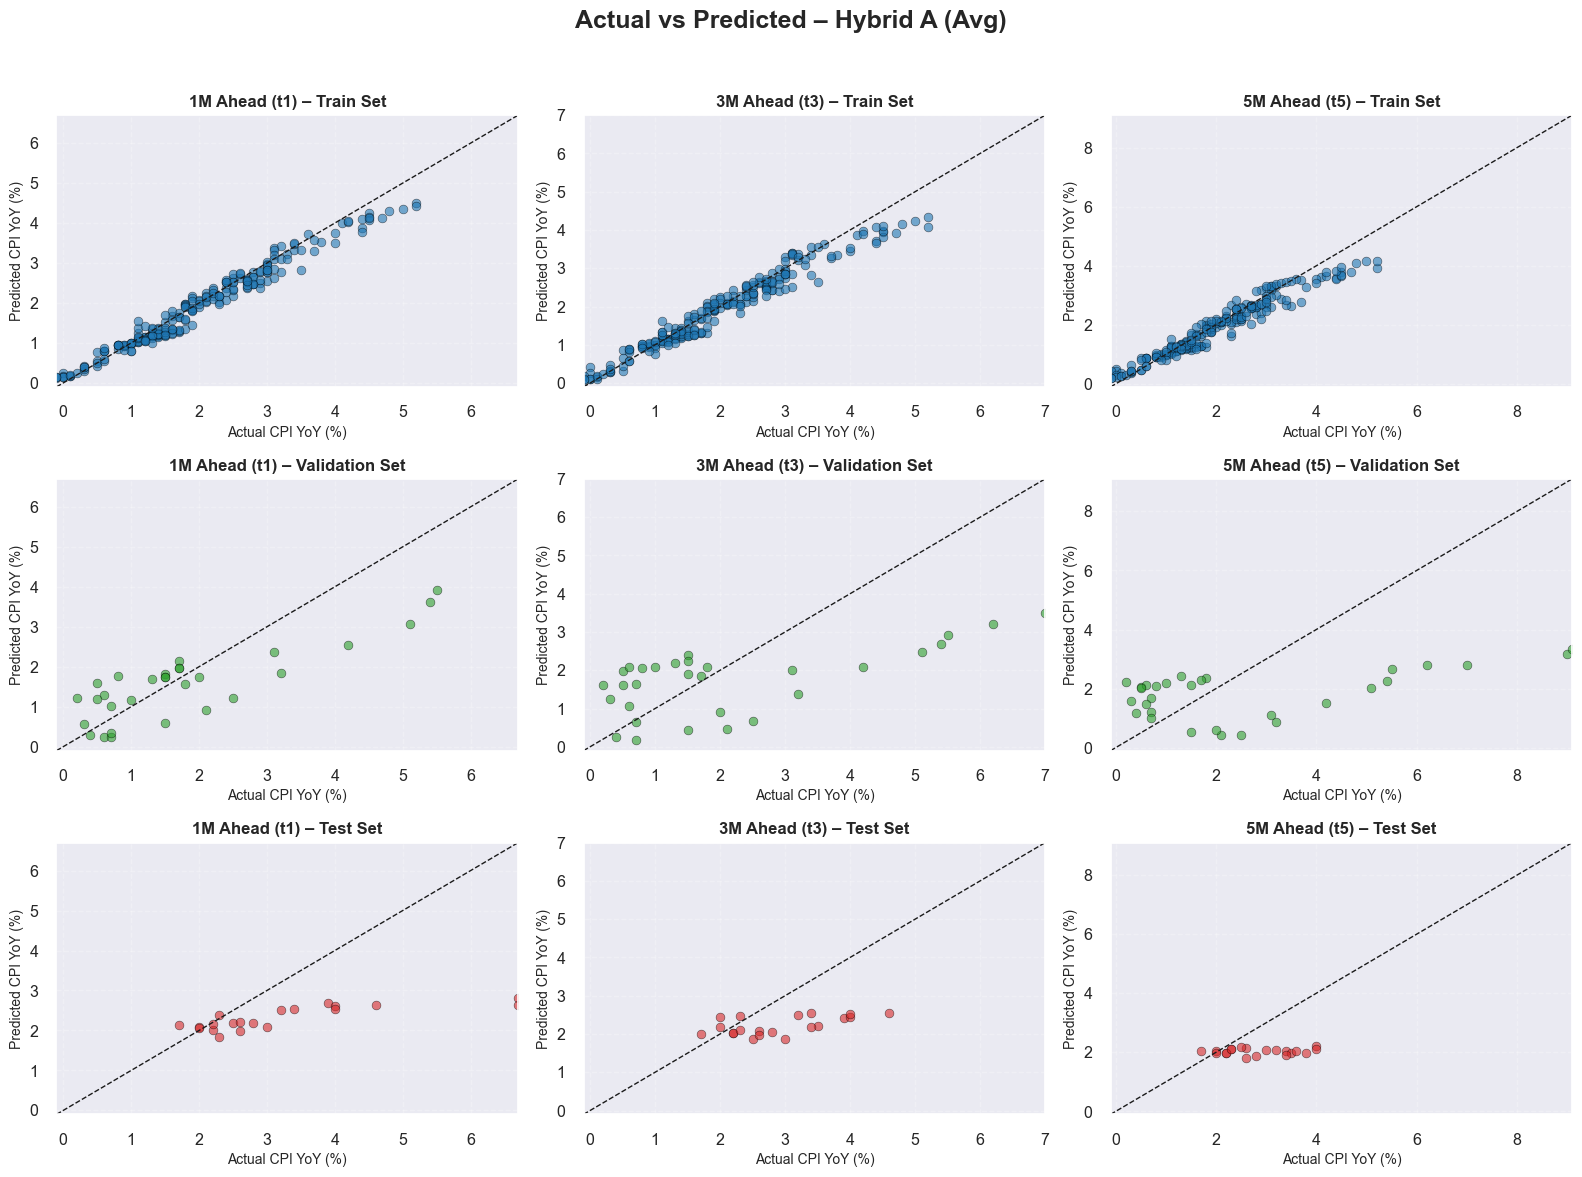

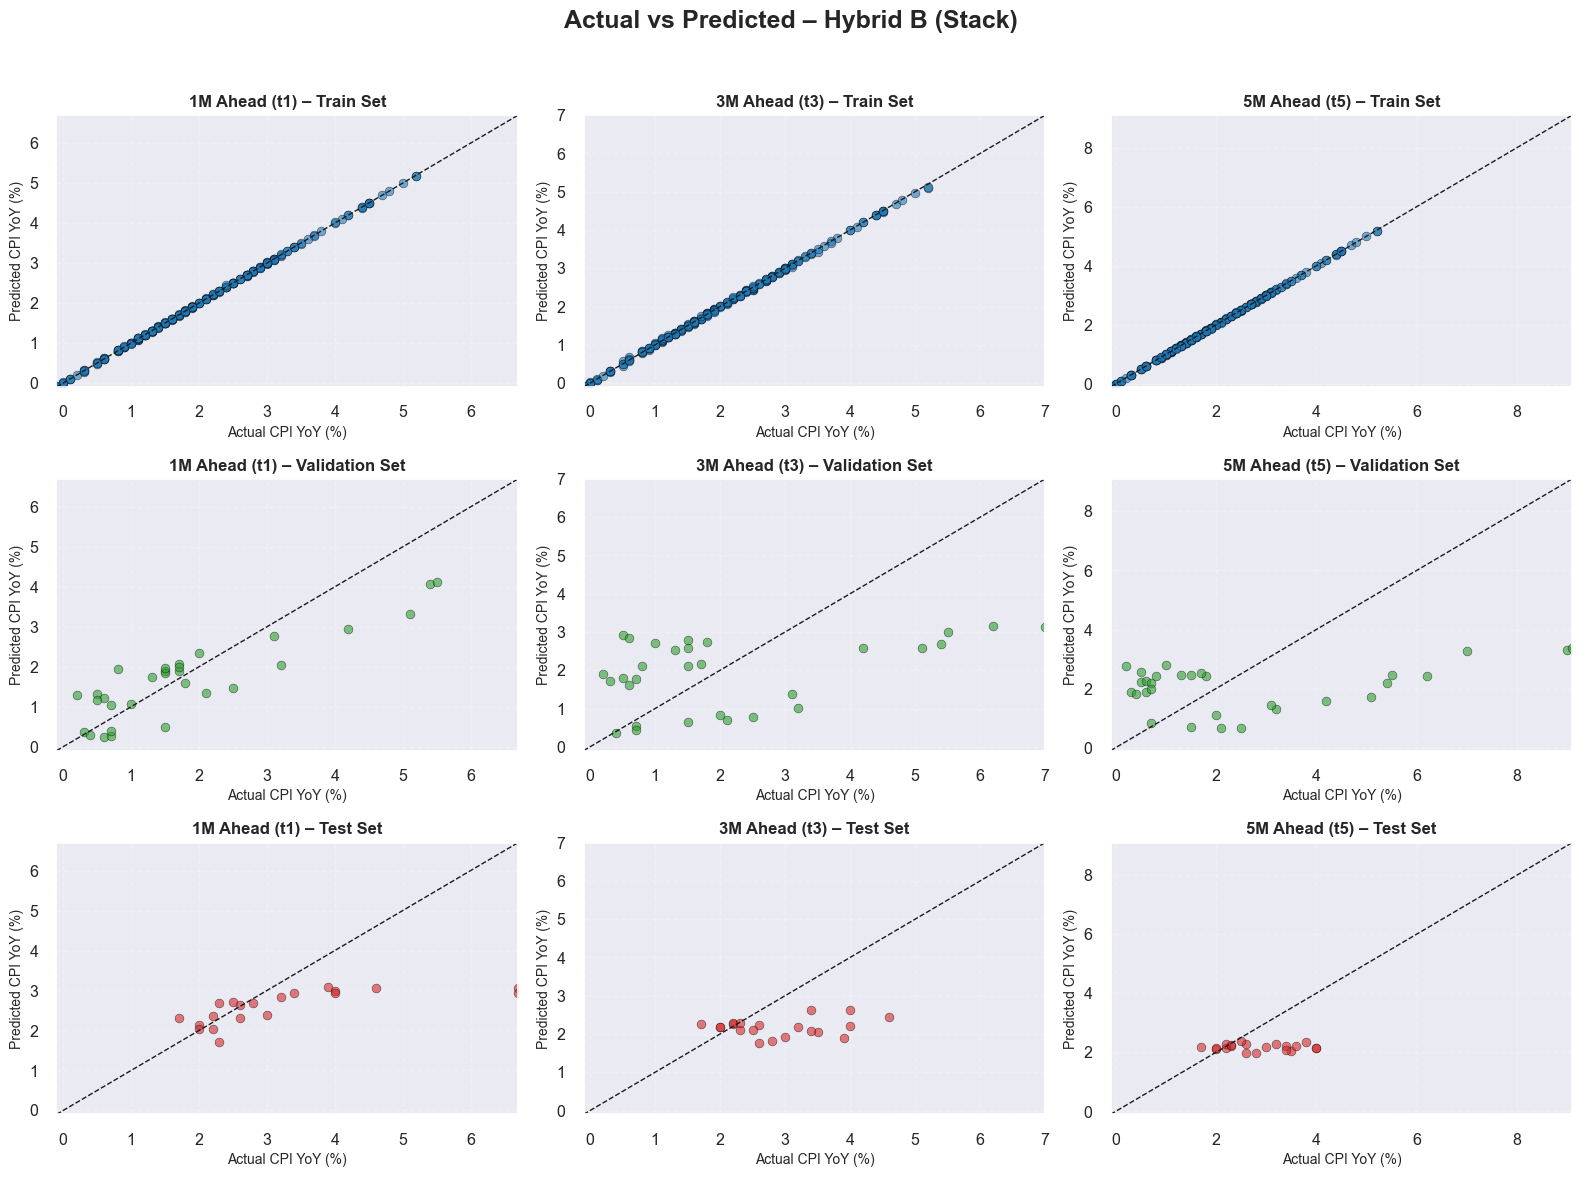

In [66]:
def plot_grid_clean(model_key, model_info, title_prefix):
    horizons = ['t1', 't3', 't5']
    horizon_labels = ['1M Ahead (t1)', '3M Ahead (t3)', '5M Ahead (t5)']
    splits = ['train', 'val', 'test']
    split_labels = ['Train Set', 'Validation Set', 'Test Set']
    colors = ['#1f77b4', '#2ca02c', '#d62728']  # blue, green, red

    # True values dictionary (already inverse scaled)
    split_true = {
        'train': y_train_actual,
        'val':   y_val_actual,
        'test':  y_test_actual
    }

    preds = model_info['preds']

    fig, axes = plt.subplots(3, 3, figsize=(16, 12))
    fig.suptitle(f"{title_prefix} – {model_info['label']}", fontsize=18, fontweight='bold')

    for col, (hidx, hlabel) in enumerate(zip([0,1,2], horizon_labels)):
        # Determine common axis limits for this horizon
        all_true = np.concatenate([split_true[s][:, hidx] for s in splits])
        all_pred = np.concatenate([preds[s][:, hidx] for s in splits])
        minv = min(all_true.min(), all_pred.min())
        maxv = max(all_true.max(), all_pred.max())

        for row, (s, slabel, color) in enumerate(zip(splits, split_labels, colors)):
            ax = axes[row, col]

            yt = split_true[s][:, hidx]
            yp = preds[s][:, hidx]

            # Scatter plot
            ax.scatter(yt, yp, alpha=0.6, s=40, color=color, edgecolor='black', linewidth=0.4)

            # Diagonal reference line
            ax.plot([minv, maxv], [minv, maxv], 'k--', linewidth=1)

            # Titles & labels
            ax.set_title(f"{hlabel} – {slabel}", fontsize=12, fontweight='bold')
            ax.set_xlabel("Actual CPI YoY (%)", fontsize=10)
            ax.set_ylabel("Predicted CPI YoY (%)", fontsize=10)

            # Limits for consistent comparison
            ax.set_xlim(minv, maxv)
            ax.set_ylim(minv, maxv)

            ax.grid(alpha=0.25, linestyle='--')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


# ---------------------
# Run for each model
# ---------------------
for key in ['lstm', 'ensA', 'ensB']:
    plot_grid_clean(key, preds_for_plot[key], title_prefix="Actual vs Predicted")


# Part III — Hybrid Ensembles (Approach A: Averaging, Approach B: Stacking)
- Approach A: Average LSTM and XGBoost scaled predictions, then inverse-scale.
- Approach B: Augment features with LSTM predictions; train XGBoost per horizon.
- Both approaches include predicted-vs-actual grids and time-series visuals.
- Benchmark performance across all splits and horizons for rigorous comparison.

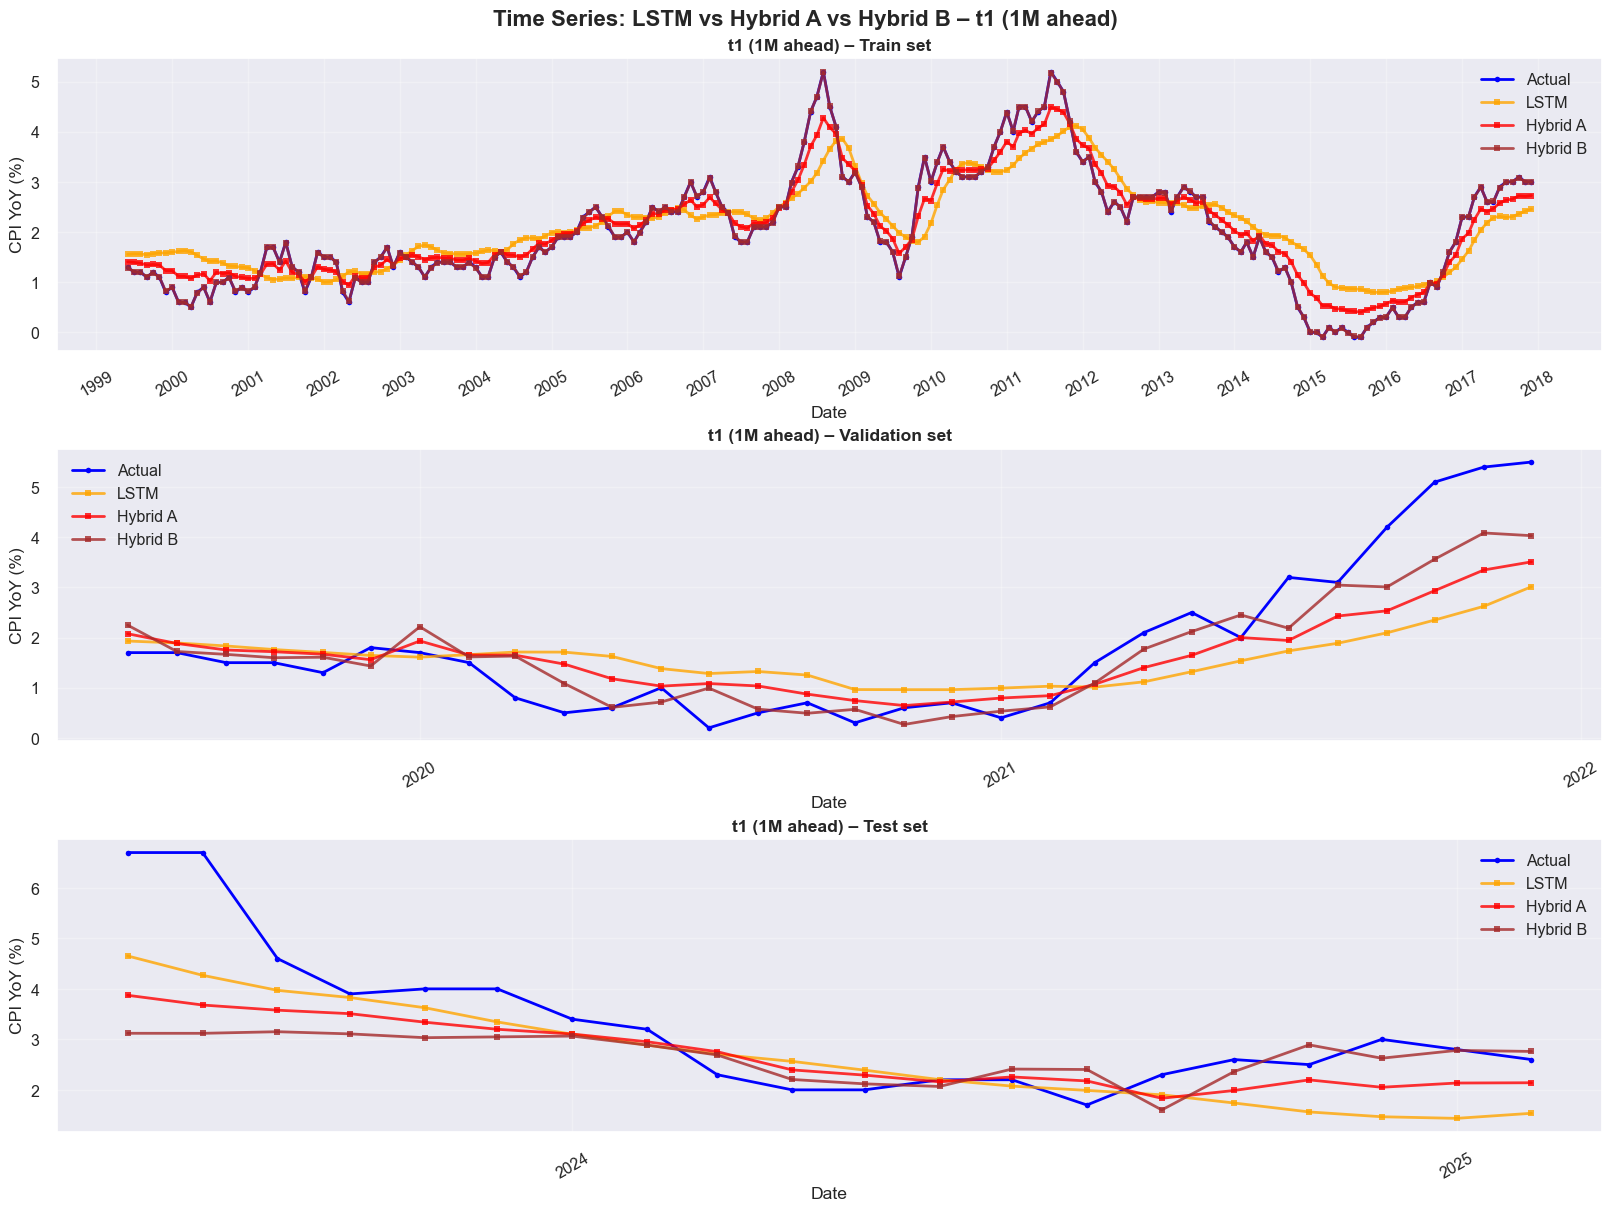

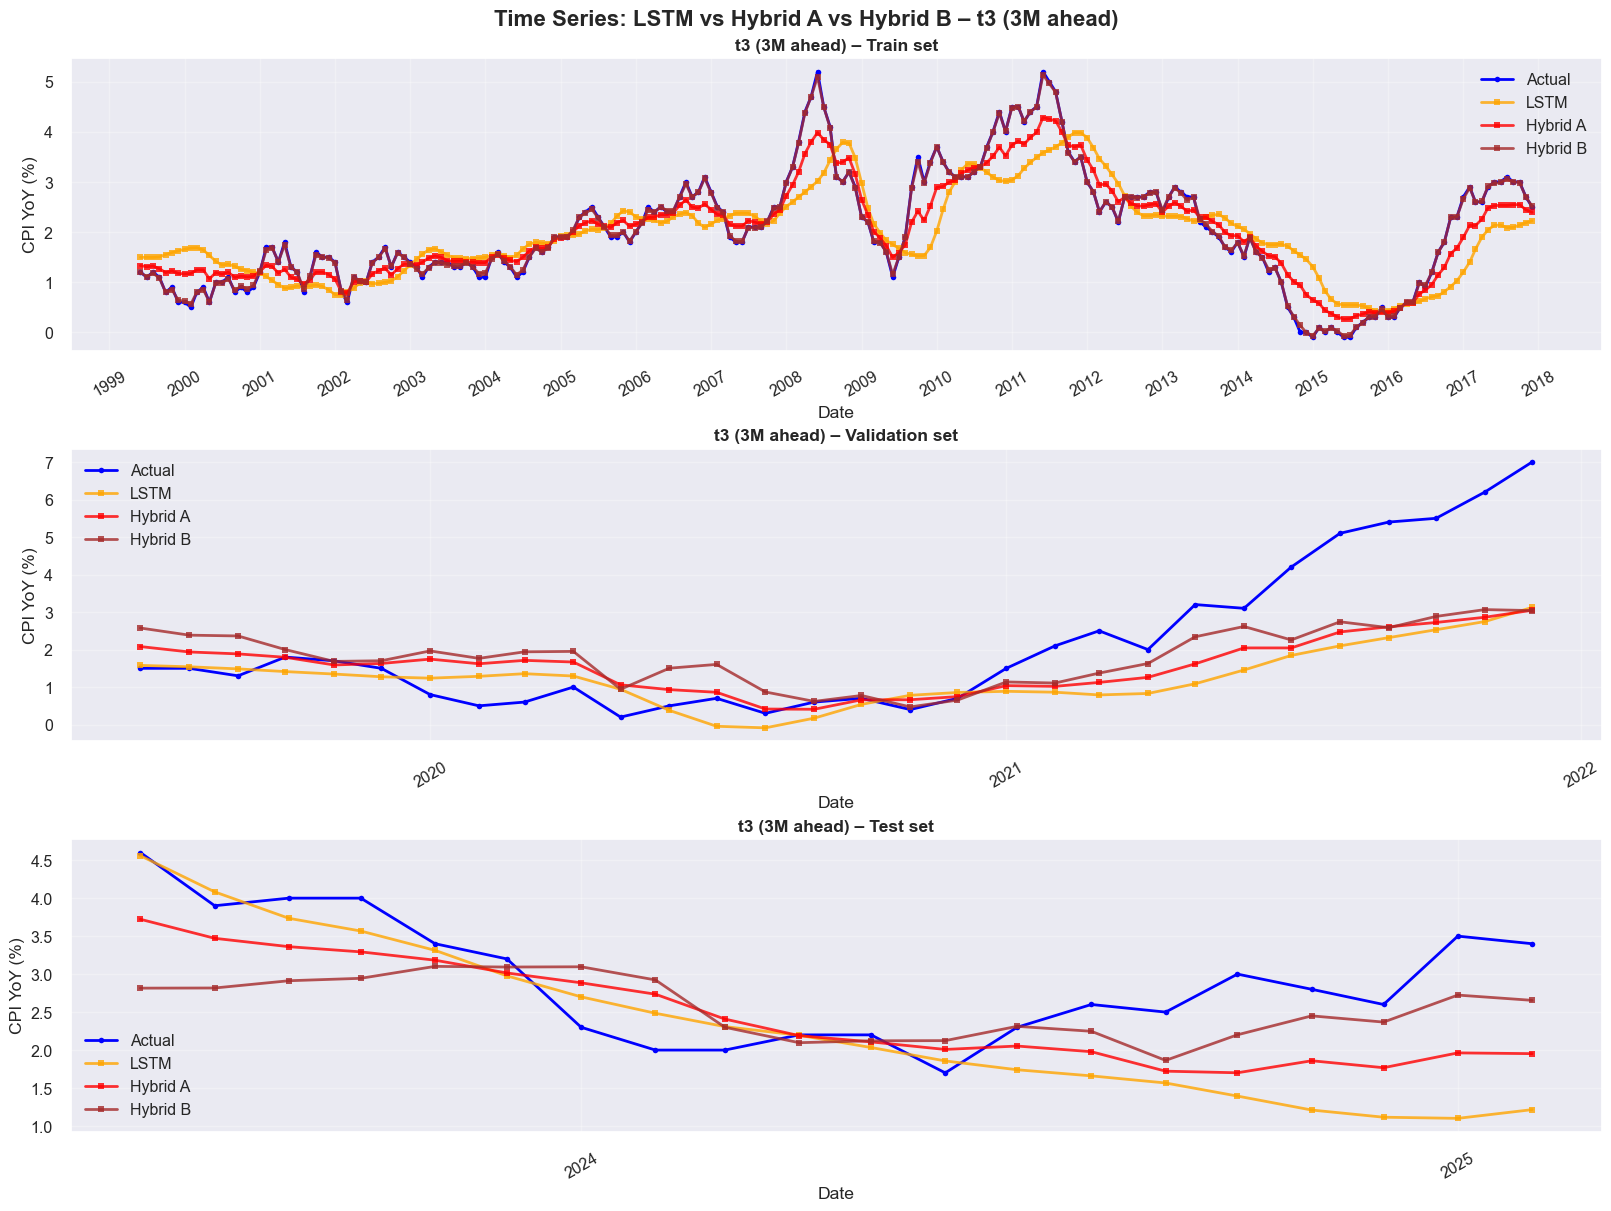

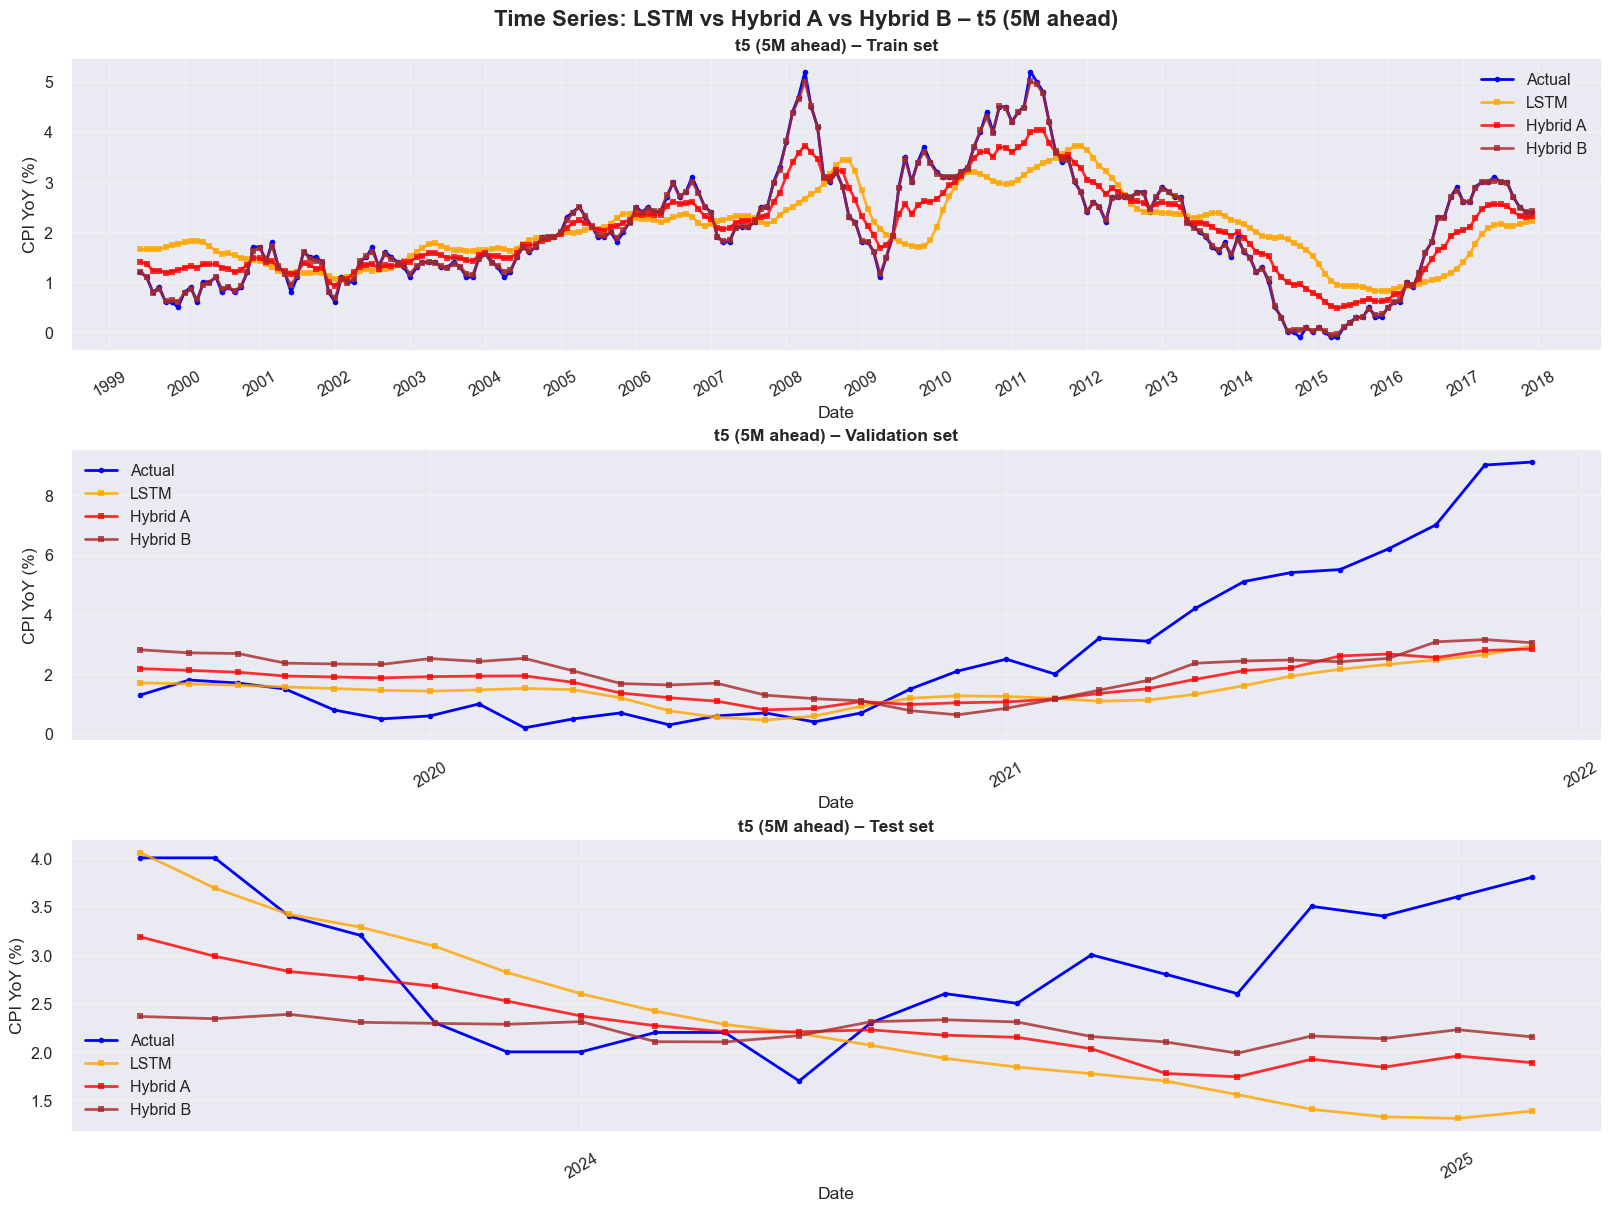

In [67]:
import matplotlib.dates as mdates

def plot_ts_all_horizons(title_prefix):
    splits = ['train', 'val', 'test']
    split_labels = {'train': 'Train', 'val': 'Validation', 'test': 'Test'}
    colors = {'LSTM': 'orange', 'Hybrid A': 'red', 'Hybrid B': 'brown'}
    horizon_indices = [0, 1, 2]
    horizon_labels = ['t1 (1M ahead)', 't3 (3M ahead)', 't5 (5M ahead)']

    # Prepare dates once
    dates_ts = {
        'train': df[train_mask]['date'].values[lookback:],
        'val':   df[val_mask]['date'].values[lookback:],
        'test':  df[test_mask]['date'].values[lookback:],
    }

    for idx, hlabel in zip(horizon_indices, horizon_labels):
        # Actual series for this horizon
        actual_ts = {
            'train': y_train_actual[:, idx],
            'val':   y_val_actual[:, idx],
            'test':  y_test_actual[:, idx],
        }

        # Predictions for this horizon
        pred_ts = {
            'LSTM': {
                'train': y_train_pred[:, idx],
                'val':   y_val_pred[:, idx],
                'test':  y_test_pred[:, idx],
            },
            'Hybrid A': {
                'train': ensembleA_train[:, idx],
                'val':   ensembleA_val[:, idx],
                'test':  ensembleA_test[:, idx],
            },
            'Hybrid B': {
                'train': ensembleB_train[:, idx],
                'val':   ensembleB_val[:, idx],
                'test':  ensembleB_test[:, idx],
            },
        }

        # Figure for this horizon: 3 rows (Train/Val/Test)
        fig, axes = plt.subplots(3, 1, figsize=(16, 12), constrained_layout=True)
        fig.suptitle(f"{title_prefix} – {hlabel}", fontsize=16, fontweight='bold')

        for i, split in enumerate(splits):
            ax = axes[i]
            dates = dates_ts[split]

            ax.plot(
                dates,
                actual_ts[split],
                'o-',
                label='Actual',
                color='blue',
                linewidth=2,
                markersize=4,
            )
            ax.plot(
                dates,
                pred_ts['LSTM'][split],
                's-',
                label='LSTM',
                color=colors['LSTM'],
                linewidth=2,
                markersize=4,
                alpha=0.8,
            )
            ax.plot(
                dates,
                pred_ts['Hybrid A'][split],
                's-',
                label='Hybrid A',
                color=colors['Hybrid A'],
                linewidth=2,
                markersize=4,
                alpha=0.8,
            )
            ax.plot(
                dates,
                pred_ts['Hybrid B'][split],
                's-',
                label='Hybrid B',
                color=colors['Hybrid B'],
                linewidth=2,
                markersize=4,
                alpha=0.8,
            )

            ax.set_title(f"{hlabel} – {split_labels[split]} set", fontweight='bold')
            ax.set_xlabel('Date')
            ax.set_ylabel('CPI YoY (%)')
            ax.grid(alpha=0.3)
            ax.legend()
            ax.tick_params(axis='x', rotation=30)

            # Clean yearly x-axis
            ax.xaxis.set_major_locator(mdates.YearLocator())
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

        plt.show()


# Call once to plot t1, t3, t5 (3 figures total)
plot_ts_all_horizons(title_prefix='Time Series: LSTM vs Hybrid A vs Hybrid B')
